# 4 — Automatic control with basic Reinforcement Learning

The previous notebooks *predict* the climate and *describe* how the systems
co-occur with it. This one closes the loop: a small agent that **chooses which
climatic system to run each hour** to keep the greenhouse near a target
temperature and humidity.

## ⚠️ Read this first — what this notebook is (and is not)

Reinforcement learning needs an **environment** to interact with. We obviously
cannot let an agent experiment on the real greenhouse, so the only option with
the data we have is **model-based / offline RL**: we build a *simulator* of the
greenhouse from the one-step (+1 h) predictive models and let the agent learn
against that simulator.

**But that simulator is built from the same observational, confounded data that
notebook 3 flagged** — fog, screens and vents were switched on *because* it was
hot (correlations +0.76 to +0.78 with interior temperature). So the agent is
optimising a **biased world-model**: it may believe that "ventilating raises the
temperature" simply because ventilation co-occurs with heat. Concretely:

* This notebook is an honest **demonstration of the RL machinery** — state,
  actions, reward, Q-learning, a learned policy, and how to evaluate it.
* It is **not** a deployable controller. Its recommendations are only as
  trustworthy as the (confounded) simulator underneath.

To make it real you would swap the simulator for one calibrated on **controlled
tests** or a **physical energy-balance model** (see notebook 3's caveat). The RL
code here would not change — only the environment it learns against.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")   # keep the training loop's stdout clean
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

from greenhouse_dataset import (
    build_hourly_dataset, make_targets, ACTIVE_START, ACTUATOR_COLS,
)

np.random.seed(0)
pd.set_option("display.width", 120)

## 4.1 — Build the one-step simulator (the "environment")

The environment must answer: *given the greenhouse state now and the systems I
switch on this hour, what are temperature and humidity **next** hour?* That is
exactly a +1 h forecast, so we train a dedicated one-step model whose inputs
include the **actuator settings as direct controls**.

Feature set (deliberately compact and Markov, so the simulator can be stepped
forward one hour at a time):

* interior state we evolve: `temp_centro`, `hum_centro`;
* exogenous weather we *replay* from history: exterior station + Open-Meteo
  forecast + time-of-day;
* the **13 actuator settings** — these are what the agent controls.

In [2]:
df = build_hourly_dataset(root=".")
df = df.loc[ACTIVE_START:].copy()          # scope to the period all systems are online

EXO = ["ext_temp", "ext_hum", "ext_rad_par", "ext_viento",
       "fc_temp", "fc_hum", "fc_rad",
       "hour_sin", "hour_cos", "doy_sin", "doy_cos"]
STATE = ["temp_centro", "hum_centro"]
SIM_FEATURES = STATE + EXO + ACTUATOR_COLS      # index 0=temp, 1=hum, last 13 = actuators

targets = make_targets(df)[["temp_h1", "hum_h1"]]
data = pd.concat([df[SIM_FEATURES], targets], axis=1).dropna()
print(f"simulator rows: {len(data)} | features: {len(SIM_FEATURES)} "
      f"({len(ACTUATOR_COLS)} of them controllable)")
print("span:", data.index.min(), "->", data.index.max())

note: fc_temp_prevday still missing 364h after the short-gap fill; bridging with an unlimited forward-fill of its own past values (flagged in fc_temp_prevday_stale)
note: fc_hum_prevday still missing 364h after the short-gap fill; bridging with an unlimited forward-fill of its own past values (flagged in fc_hum_prevday_stale)
note: fc_viento_prevday still missing 260h after the short-gap fill; bridging with an unlimited forward-fill of its own past values (flagged in fc_viento_prevday_stale)
simulator rows: 1505 | features: 26 (13 of them controllable)
span: 2026-04-24 00:00:00 -> 2026-07-13 21:00:00


In [3]:
# chronological 80/20 split (never shuffle a time series)
cut = int(len(data) * 0.80)
tr, te = data.iloc[:cut], data.iloc[cut:]

sim = MultiOutputRegressor(
    HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, random_state=0))
# fit on plain arrays so stepping the env with numpy rows never triggers a
# feature-name mismatch warning (this loop runs tens of thousands of times).
sim.fit(tr[SIM_FEATURES].values, tr[["temp_h1", "hum_h1"]].values)

def cvrmse(yt, yp):
    return root_mean_squared_error(yt, yp) / np.mean(yt)

pred = sim.predict(te[SIM_FEATURES].values)
print("Simulator accuracy on the hold-out (this is the ceiling on how much the")
print("agent can be trusted):")
for j, name in enumerate(["temp_h1 (degC)", "hum_h1 (%)"]):
    mae = mean_absolute_error(te[["temp_h1", "hum_h1"]].values[:, j], pred[:, j])
    cv  = cvrmse(te[["temp_h1", "hum_h1"]].values[:, j], pred[:, j])
    print(f"  {name:16s}  MAE={mae:5.2f}   CVRMSE={cv:5.3f}")

Simulator accuracy on the hold-out (this is the ceiling on how much the
agent can be trusted):
  temp_h1 (degC)    MAE= 0.70   CVRMSE=0.034
  hum_h1 (%)        MAE= 2.15   CVRMSE=0.040


## 4.2 — The decision problem (states, actions, reward)

**Target setpoint.** We aim for **24 °C** and **65 % RH** — change `T_SET`/`H_SET`
to control toward a different climate.

**Actions.** Rather than 13 independent knobs (an intractable action space), we
use six interpretable **macro-actions**, each a preset of actuator minutes,
inspired directly by the operating states found in notebook 1:

In [4]:
T_SET, H_SET = 24.0, 65.0
ON = 60.0        # a macro-action runs a device for the full hour

ACTIONS = {
    "passive":      {},                                                   # everything off
    "heat":         {"act_calefactores": ON},
    "ventilate":    {"act_vent_cen_este": ON, "act_vent_cen_oeste": ON,
                     "act_vent_lat_norte": ON, "act_vent_lat_oeste": ON,
                     "act_vent_lat_sur": ON},
    "fog_cool":     {"act_fog": ON, "act_bomba_fog": ON},
    "shade+vent":   {"act_pantalla_cenital": ON, "act_pantalla_lat_sur": ON,
                     "act_vent_cen_este": ON, "act_vent_cen_oeste": ON},
    "recirculate":  {"act_recirculador": ON, "act_recirculador2": ON},
}
ACTION_NAMES = list(ACTIONS)
N_ACTIONS = len(ACTION_NAMES)

# pre-compute each action as a length-13 actuator vector (module column order)
ACTION_VECS = np.zeros((N_ACTIONS, len(ACTUATOR_COLS)))
for a, name in enumerate(ACTION_NAMES):
    for col, val in ACTIONS[name].items():
        ACTION_VECS[a, ACTUATOR_COLS.index(col)] = val
print(f"{N_ACTIONS} macro-actions:", ACTION_NAMES)

6 macro-actions: ['passive', 'heat', 'ventilate', 'fog_cool', 'shade+vent', 'recirculate']


**State (discretised).** Q-learning here is *tabular*, so we bin the continuous
climate into a small, human-readable state: a temperature band × a humidity band
× a coarse time-of-day. The simulator still runs on continuous values — only the
Q-table key is discretised.

**Reward.** The agent is penalised for being far from the setpoint, with
temperature and humidity put on comparable scales:
`reward = -( |T - 24|/2  +  |H - 65|/10 )`.

In [5]:
TEMP_EDGES = [20, 23, 26, 29]        # -> 5 bands
HUM_EDGES  = [45, 60, 75]            # -> 4 bands
N_TB, N_HB, N_PB = len(TEMP_EDGES) + 1, len(HUM_EDGES) + 1, 4   # 4 dayparts
N_STATES = N_TB * N_HB * N_PB

def discretise(temp, hum, hour):
    tb = int(np.digitize(temp, TEMP_EDGES))
    hb = int(np.digitize(hum, HUM_EDGES))
    pb = int(hour) // 6                       # night / morning / midday / evening
    return (tb * N_HB + hb) * N_PB + pb

def reward(temp, hum):
    return -(abs(temp - T_SET) / 2.0 + abs(hum - H_SET) / 10.0)

print(f"state space: {N_TB} temp x {N_HB} hum x {N_PB} dayparts = {N_STATES} states")

state space: 5 temp x 4 hum x 4 dayparts = 80 states


## 4.3 — Stepping the environment

One environment step takes the current interior climate + the *real* exogenous
weather for that historical hour + the agent's chosen action, and returns next
hour's interior climate from the simulator. The weather is **replayed from
actual consecutive hours**, so the agent faces realistic exterior conditions it
cannot control — it only decides which systems to run.

In [6]:
BASE = df[SIM_FEATURES].values.astype(float)   # historical rows (aligned to df index)
HOURS = df["hour"].values.astype(int)
N = len(BASE)
ACT_SLICE = slice(len(STATE) + len(EXO), len(SIM_FEATURES))   # last 13 cols

def step(row_i, temp, hum, action):
    """Predict next (temp, hum) at historical row `row_i` under `action`."""
    x = BASE[row_i].copy()
    x[0], x[1] = temp, hum                     # override interior state
    x[ACT_SLICE] = ACTION_VECS[action]         # override actuators with the action
    temp1, hum1 = sim.predict(x[None])[0]
    return float(temp1), float(hum1)

# episode start indices, split by time so evaluation days are unseen during training
EP_LEN = 24
usable = N - EP_LEN - 1
split = int(usable * 0.80)
train_starts = np.arange(0, split)
eval_starts  = np.arange(split, usable)
print(f"{len(train_starts)} training start-hours, {len(eval_starts)} evaluation start-hours "
      f"(episode length {EP_LEN} h)")

1534 training start-hours, 384 evaluation start-hours (episode length 24 h)


## 4.4 — Train the agent (tabular Q-learning)

Standard Q-learning: from each state the agent picks an action (ε-greedy),
observes the reward and next state from the simulator, and nudges its value
estimate `Q[s, a]` toward `reward + γ · max_a' Q[s', a']`. ε decays so it
explores early and exploits later.

In [7]:
ALPHA, GAMMA = 0.15, 0.90
N_EPISODES = 3000
eps0, eps_min = 0.9, 0.05

Q = np.zeros((N_STATES, N_ACTIONS))
returns = []

for ep in range(N_EPISODES):
    eps = max(eps_min, eps0 * (1 - ep / N_EPISODES))
    i0 = np.random.choice(train_starts)
    temp, hum = BASE[i0, 0], BASE[i0, 1]
    ep_ret = 0.0
    for t in range(EP_LEN):
        i = i0 + t
        s = discretise(temp, hum, HOURS[i])
        a = np.random.randint(N_ACTIONS) if np.random.rand() < eps else int(Q[s].argmax())
        temp1, hum1 = step(i, temp, hum, a)
        r = reward(temp1, hum1)
        s1 = discretise(temp1, hum1, HOURS[i + 1])
        Q[s, a] += ALPHA * (r + GAMMA * Q[s1].max() - Q[s, a])
        temp, hum = temp1, hum1
        ep_ret += r
    returns.append(ep_ret / EP_LEN)      # mean reward per hour

print(f"trained {N_EPISODES} episodes | visited "
      f"{(Q != 0).any(axis=1).sum()}/{N_STATES} states")

trained 3000 episodes | visited 64/80 states


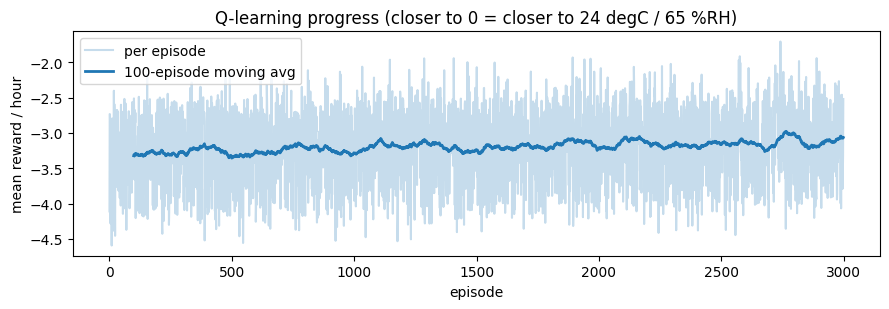

In [8]:
# learning curve: mean hourly reward (higher = closer to setpoint), smoothed
roll = pd.Series(returns).rolling(100).mean()
plt.figure(figsize=(9, 3.2))
plt.plot(returns, alpha=0.25, color="tab:blue", label="per episode")
plt.plot(roll, color="tab:blue", lw=2, label="100-episode moving avg")
plt.xlabel("episode"); plt.ylabel("mean reward / hour")
plt.title("Q-learning progress (closer to 0 = closer to 24 degC / 65 %RH)")
plt.legend(); plt.tight_layout(); plt.show()

## 4.5 — Does the learned policy actually control better?

We roll the greedy learned policy over the **held-out** evaluation start-hours
and compare it against sensible references:

* **passive** — do nothing (all systems off);
* **always ventilate** — a naive fixed rule;
* **MPC-greedy (1-step)** — at each hour, try *all* actions in the simulator and
  pick the one with the best immediate predicted climate. This is a strong,
  simpler alternative; a good RL policy should approach it.

Metric = mean absolute distance to the setpoint (°C for temperature, %RH for
humidity), averaged over all evaluation episodes.

In [9]:
def rollout(policy, starts):
    """policy(s, i, temp, hum) -> action. Returns (mean|dT|, mean|dH|)."""
    dT, dH = [], []
    for i0 in starts:
        temp, hum = BASE[i0, 0], BASE[i0, 1]
        for t in range(EP_LEN):
            i = i0 + t
            s = discretise(temp, hum, HOURS[i])
            a = policy(s, i, temp, hum)
            temp, hum = step(i, temp, hum, a)
            dT.append(abs(temp - T_SET)); dH.append(abs(hum - H_SET))
    return float(np.mean(dT)), float(np.mean(dH))

def mpc_greedy(s, i, temp, hum):
    best, ba = 1e9, 0
    for a in range(N_ACTIONS):
        t1, h1 = step(i, temp, hum, a)
        c = -reward(t1, h1)
        if c < best:
            best, ba = c, a
    return ba

policies = {
    "passive (off)":     lambda s, i, t, h: ACTION_NAMES.index("passive"),
    "always ventilate":  lambda s, i, t, h: ACTION_NAMES.index("ventilate"),
    "RL (learned Q)":    lambda s, i, t, h: int(Q[s].argmax()),
    "MPC-greedy 1-step":  mpc_greedy,
}

rows = {name: rollout(pol, eval_starts) for name, pol in policies.items()}
evaldf = pd.DataFrame(rows, index=["|T-24| (degC)", "|H-65| (%RH)"]).T
evaldf["combined cost"] = evaldf["|T-24| (degC)"] / 2 + evaldf["|H-65| (%RH)"] / 10
evaldf.round(2)

,|T-24| (degC),|H-65| (%RH),combined cost
passive (off),4.62,8.39,3.15
always ventilate,4.55,8.04,3.08
RL (learned Q),4.63,7.39,3.05
MPC-greedy 1-step,4.42,4.50,2.66


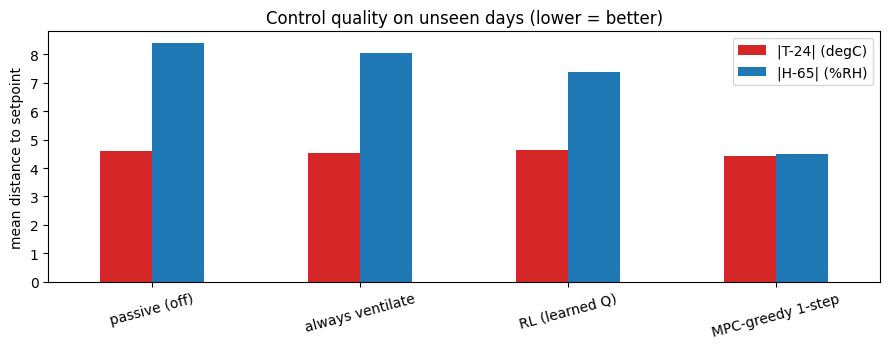

In [10]:
ax = evaldf[["|T-24| (degC)", "|H-65| (%RH)"]].plot.bar(
    figsize=(9, 3.6), rot=15, color=["tab:red", "tab:blue"])
ax.set_ylabel("mean distance to setpoint")
ax.set_title("Control quality on unseen days (lower = better)")
plt.tight_layout(); plt.show()

### A single day, hour by hour

One evaluation day under three policies, so you can see the behaviour rather than
just the average.

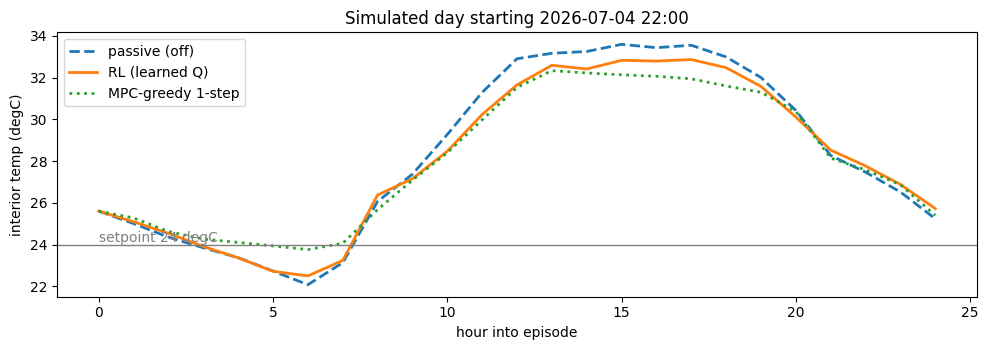

In [11]:
def trace(policy, i0):
    temps = [BASE[i0, 0]]
    hum = BASE[i0, 1]; temp = temps[0]; acts = []
    for t in range(EP_LEN):
        i = i0 + t
        s = discretise(temp, hum, HOURS[i])
        a = policy(s, i, temp, hum)
        acts.append(a)
        temp, hum = step(i, temp, hum, a)
        temps.append(temp)
    return temps, acts

i0 = eval_starts[len(eval_starts) // 2]
fig, ax = plt.subplots(figsize=(10, 3.6))
for name, style in [("passive (off)", "--"), ("RL (learned Q)", "-"),
                    ("MPC-greedy 1-step", ":")]:
    temps, _ = trace(policies[name], i0)
    ax.plot(range(EP_LEN + 1), temps, style, lw=2, label=name)
ax.axhline(T_SET, color="grey", lw=1); ax.text(0, T_SET + 0.15, "setpoint 24 degC", color="grey")
ax.set_xlabel("hour into episode"); ax.set_ylabel("interior temp (degC)")
ax.set_title(f"Simulated day starting {df.index[i0]:%Y-%m-%d %H:%M}")
ax.legend(); plt.tight_layout(); plt.show()

## 4.6 — The learned policy, made readable

For the **midday** daypart, which action does the agent choose in each
temperature × humidity cell? This is the human-inspectable output of the whole
exercise — and where you can sanity-check it against physical intuition (and spot
where the confounded simulator misleads it).

In [12]:
daypart = 2   # midday (hours 12-17)
temp_labels = ["<20", "20-23", "23-26", "26-29", ">29"]
hum_labels  = ["<45", "45-60", "60-75", ">75"]
grid = pd.DataFrame(index=temp_labels, columns=hum_labels, dtype=object)
for tb in range(N_TB):
    for hb in range(N_HB):
        s = (tb * N_HB + hb) * N_PB + daypart
        grid.iloc[tb, hb] = ACTION_NAMES[int(Q[s].argmax())] if Q[s].any() else "-"
grid.index.name = "temp \\ hum"
print("Learned midday policy (rows = interior temp, cols = interior humidity):")
grid

Learned midday policy (rows = interior temp, cols = interior humidity):


,<45,45-60,60-75,>75
temp \ hum,,,,
<20,-,heat,heat,-
20-23,ventilate,heat,shade+vent,-
23-26,fog_cool,ventilate,recirculate,-
26-29,passive,ventilate,passive,-
>29,passive,fog_cool,fog_cool,passive


In [13]:
# persist the policy for reuse / inspection
import os
os.makedirs("model data", exist_ok=True)
policy_long = []
for st in range(N_STATES):
    if not Q[st].any():
        continue
    tb = st // (N_HB * N_PB); hb = (st // N_PB) % N_HB; pb = st % N_PB
    policy_long.append({"temp_band": temp_labels[tb], "hum_band": hum_labels[hb],
                        "daypart": pb, "action": ACTION_NAMES[int(Q[st].argmax())],
                        "value": round(float(Q[st].max()), 3)})
pd.DataFrame(policy_long).to_csv("model data/rl_policy.csv", index=False)
print("saved learned policy ->", "model data/rl_policy.csv",
      f"({len(policy_long)} visited states)")

saved learned policy -> model data/rl_policy.csv (64 visited states)


## Summary

* We framed greenhouse regulation as a **Markov decision process** and solved it
  with **tabular Q-learning**, using the +1 h models as a one-step simulator and
  replaying real exterior weather.
* The learned policy is **readable** (a temp × humidity → action table) and, on
  unseen simulated days, should track the setpoint better than doing nothing and
  approach the 1-step MPC reference.

### The honest bottom line

The agent optimises against a **confounded** world-model, so its choices can be
physically wrong (e.g. it may under-value ventilation because, in the data,
ventilation coincided with heat rather than causing cooling). Compare the learned
policy table with the MPC baseline and with physical intuition — where they
disagree is exactly where the observational bias bites.

**This is the RL scaffolding, ready to become a real controller the moment the
simulator is replaced by one built from controlled experiments or a calibrated
energy-balance model.** Everything above it — state, actions, reward, learning,
evaluation, the policy table — stays the same.